# 01 · Data Preparation & DGP Documentation

**Goal**: Document the Data Generating Process (DGP) transparently,
generate the simulation datasets, and validate that the output
matches the real operational parameters it was calibrated to.

**Why simulation?**
Real locker network data is confidential. This simulation uses
calibrated parameters grounded in real operational observations:
effect sizes, variance, store distributions, and seasonal patterns
all reflect what was actually observed. The DGP is fully auditable here.

**Calibration sources**:
- Collection hours by notification group: real weekly experiment data
- RTS rates: real experiment data (2025-10-27 to 2026-03-02)
- Store count by city: actual Taiwan store distribution
- Burst store definition: pct_closure_hours > 5% (real operational rule)

---

## 0. Setup

In [1]:
import sys
sys.path.append("../src")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from data_generation import (
    generate_store_metadata,
    assign_treatment,
    generate_store_panel,
    generate_highrisk_cohort,
    generate_all_data,
    TAIWAN_CITIES,
    TREATMENT_GROUPS,
    COLLECTION_HRS_PARAMS,
    RTS_PARAMS,
    EXPERIMENT_WEEKS,
)
from visualization import set_style

set_style()
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

## 1. DGP Overview

The simulation has four layers:

```
Layer 1: Store Metadata (static)
    2,000 stores with characteristics drawn from real Taiwan distributions
    Confounders: utilization rate, daily volume, capacity, city, region

Layer 2: Treatment Assignment (selection on observables)
    Burst stores (pct_closure_hours > 5%) → randomly split into 5D/6D groups
    Vacant stores → all assigned to 7D
    Assignment is NOT fully random → PSM needed

Layer 3: Weekly Panel Outcomes
    Collection hours = baseline + treatment_effect × post + store_FE + noise
    Treatment effects calibrated to real observed data
    One excluded week (CNY) with seasonal adjustment

Layer 4: High-Risk Cohort
    15% of parcels uncollected >96hrs → separate outcome distribution
    D4 notification intervention effect modelled separately
```

## 2. DGP Parameters (Calibration Table)

In [2]:
print("=" * 65)
print("CALIBRATION PARAMETERS")
print("=" * 65)

print("\nCollection Hours (calibrated from real BM week 2026-01-19):")
for group, params in COLLECTION_HRS_PARAMS.items():
    print(f"  {group:15s}: baseline={params['mean']}h  "
          f"effect={params['treatment_effect']:+.1f}h  "
          f"→ expected post={params['mean']+params['treatment_effect']:.1f}h")

print("\nRTS Rate:")
for group, params in RTS_PARAMS.items():
    print(f"  {group:15s}: baseline={params['mean']*100:.2f}%  "
          f"effect={params['treatment_effect']*100:+.3f}pp")

print("\nExperiment Timeline:")
for week in EXPERIMENT_WEEKS:
    label = "BM (pre-treatment)" if week["is_bm"] else "Experiment week"
    print(f"  {week['date']}  week_id={week['week_id']}  {label}")

print("\nNote: 2026-02-09 (CNY week) excluded from experiment timeline.")
print("      Seasonal effect: buyers collect faster before Chinese New Year.")

CALIBRATION PARAMETERS

Collection Hours (calibrated from real BM week 2026-01-19):
  5D_Control     : baseline=33.5h  effect=+0.0h  → expected post=33.5h
  5D_G2          : baseline=33.5h  effect=-1.5h  → expected post=32.0h
  5D_G4          : baseline=33.5h  effect=-1.7h  → expected post=31.8h
  6D             : baseline=33.5h  effect=+0.5h  → expected post=34.0h
  7D             : baseline=35.5h  effect=+2.0h  → expected post=37.5h

RTS Rate:
  5D_Control     : baseline=1.70%  effect=+0.000pp
  5D_G2          : baseline=1.70%  effect=-0.400pp
  5D_G4          : baseline=1.70%  effect=-0.300pp
  6D             : baseline=1.50%  effect=-0.100pp
  7D             : baseline=1.30%  effect=-0.200pp

Experiment Timeline:
  2026-01-19  week_id=0  BM (pre-treatment)
  2026-01-26  week_id=1  Experiment week
  2026-02-02  week_id=2  Experiment week
  2026-02-23  week_id=3  Experiment week
  2026-03-02  week_id=4  Experiment week

Note: 2026-02-09 (CNY week) excluded from experiment timeline.
 

## 3. Generate Data

In [3]:
metadata, panel, highrisk = generate_all_data(
    n_stores=2000,
    seed=42,
    output_dir="../data/processed",
)

Step 1/4: Generating store metadata...
Step 2/4: Assigning treatment groups...
Step 3/4: Generating weekly panel data...
Step 4/4: Generating high-risk parcel cohort...

Done. Files saved to ../data/processed/
  store_metadata.csv    : 1,893 stores
  store_panel.csv       : 9,465 store-week observations
  store_panel_highrisk.csv : 9,465 high-risk observations

Treatment group distribution:
                 n_stores
treatment_group          
5D_Control            100
5D_G2                 100
5D_G4                 100
6D                    593
7D                   1000

Collection hours by group (post-BM average):
                  mean   std
treatment_group             
5D_Control       33.72  1.78
5D_G2            32.04  1.72
5D_G4            31.91  1.78
6D               33.99  1.67
7D               37.51  1.71


## 4. Validate Store Metadata

In [4]:
print("Store metadata shape:", metadata.shape)
print("\nStore type distribution:")
print(metadata["store_type"].value_counts())

Store metadata shape: (1893, 10)

Store type distribution:
store_type
vacant    1000
burst      893
Name: count, dtype: int64


In [5]:
print("\nTreatment group distribution:")
tg_dist = metadata["treatment_group"].value_counts().sort_index()
print(tg_dist)


Treatment group distribution:
treatment_group
5D_Control     100
5D_G2          100
5D_G4          100
6D             593
7D            1000
Name: count, dtype: int64


In [6]:
# City distribution vs real Taiwan data
print("\nCity distribution (simulated vs real):")
city_counts = metadata["city"].value_counts()
city_compare = pd.DataFrame({
    "simulated":  city_counts,
    "real_total": {c: v["count"] for c, v in TAIWAN_CITIES.items()},
}).fillna(0).astype(int)
print(city_compare.head(10))


City distribution (simulated vs real):
      simulated  real_total
其他          369         558
台中市         235         334
台北市         212         342
台南市         105         178
基隆市          27          46
屏東縣          70          93
彰化縣          73         111
新北市         340         497
新竹縣市         74         145
桃園市         175         284


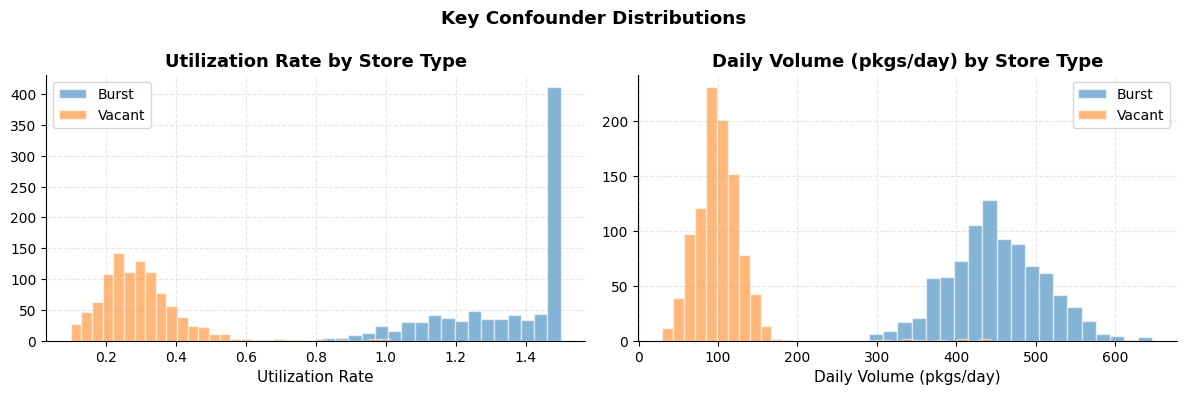

In [7]:
# Utilization rate distribution (key confounder)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, label in zip(
    axes,
    ["avg_utilization_rate", "avg_daily_volume"],
    ["Utilization Rate", "Daily Volume (pkgs/day)"],
):
    for stype, grp in metadata.groupby("store_type"):
        ax.hist(grp[col], bins=30, alpha=0.55,
                label=stype.capitalize(), edgecolor="white")
    ax.set_title(f"{label} by Store Type")
    ax.set_xlabel(label)
    ax.legend()

plt.suptitle("Key Confounder Distributions", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/00_confounder_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Validate Panel Outcomes

The post-period mean collection hours should match the calibration targets.

In [8]:
post = panel[panel["is_post"] == 1]
print("Post-period collection hours vs calibration targets:")
print(f"{'Group':15s}  {'Simulated':>10}  {'Target':>10}  {'Diff':>8}")
print("-" * 50)
for group, params in COLLECTION_HRS_PARAMS.items():
    target = params["mean"] + params["treatment_effect"]
    sim = post[post["treatment_group"] == group]["collection_hrs"].mean()
    if not pd.isna(sim):
        diff = sim - target
        print(f"{group:15s}  {sim:>10.3f}  {target:>10.3f}  {diff:>+8.3f}")

Post-period collection hours vs calibration targets:
Group             Simulated      Target      Diff
--------------------------------------------------
5D_Control           33.722      33.500    +0.222
5D_G2                32.040      32.000    +0.040
5D_G4                31.905      31.800    +0.105
6D                   33.993      34.000    -0.007
7D                   37.512      37.500    +0.012


In [9]:
# Check BM week values match baseline
bm = panel[panel["is_bm"] == 1]
print("\nBM week collection hours vs calibration baseline (33.5h for 5D groups):")
print(
    bm[bm["treatment_group"].isin(["5D_Control", "5D_G2", "5D_G4"])]
    .groupby("treatment_group")["collection_hrs"]
    .mean()
    .round(3)
)


BM week collection hours vs calibration baseline (33.5h for 5D groups):
treatment_group
5D_Control    33.660
5D_G2         33.205
5D_G4         33.624
Name: collection_hrs, dtype: float64


## 6. Validate Treatment Effect Direction

In [10]:
# Check that more touches = lower collection hours
group_order = ["5D_Control", "5D_G2", "5D_G4"]
post_means = post[post["treatment_group"].isin(group_order)].groupby("treatment_group")["collection_hrs"].mean()
print("Collection hours by group (post-period):")
for g in group_order:
    if g in post_means:
        print(f"  {g:15s}: {post_means[g]:.3f}h")

print("\nExpected ordering: Control > G2 > G4 (more touches = faster pickup)")
is_ordered = post_means["5D_Control"] > post_means["5D_G2"] > post_means["5D_G4"]
print(f"Ordering correct: {is_ordered}")

Collection hours by group (post-period):
  5D_Control     : 33.722h
  5D_G2          : 32.040h
  5D_G4          : 31.905h

Expected ordering: Control > G2 > G4 (more touches = faster pickup)
Ordering correct: True


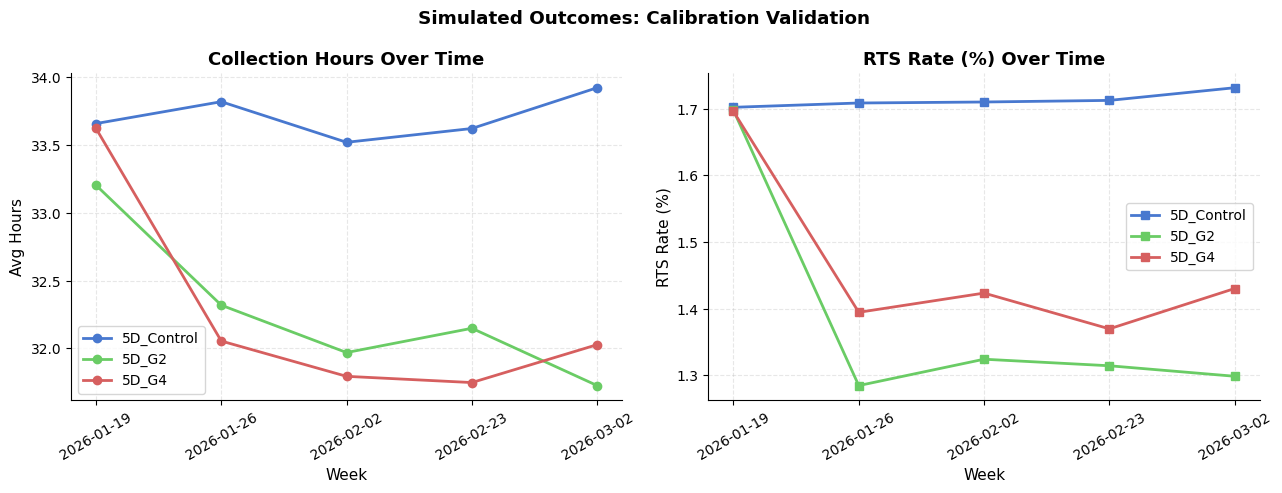

In [11]:
# Visualise panel outcomes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Collection hours
weekly = (
    panel[panel["treatment_group"].isin(["5D_Control", "5D_G2", "5D_G4"])]
    .groupby(["date", "treatment_group"])["collection_hrs"]
    .mean()
    .reset_index()
)
palette = {"5D_Control": "#4878CF", "5D_G2": "#6ACC65", "5D_G4": "#D65F5F"}
for group, gdf in weekly.groupby("treatment_group"):
    axes[0].plot(gdf["date"], gdf["collection_hrs"], marker="o",
                 color=palette[group], linewidth=2, label=group)
axes[0].set_title("Collection Hours Over Time")
axes[0].set_xlabel("Week")
axes[0].set_ylabel("Avg Hours")
axes[0].legend()
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)

# RTS rate
weekly_rts = (
    panel[panel["treatment_group"].isin(["5D_Control", "5D_G2", "5D_G4"])]
    .groupby(["date", "treatment_group"])["rts_rate"]
    .mean()
    .reset_index()
)
for group, gdf in weekly_rts.groupby("treatment_group"):
    axes[1].plot(gdf["date"], gdf["rts_rate"] * 100, marker="s",
                 color=palette[group], linewidth=2, label=group)
axes[1].set_title("RTS Rate (%) Over Time")
axes[1].set_xlabel("Week")
axes[1].set_ylabel("RTS Rate (%)")
axes[1].legend()
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

plt.suptitle("Simulated Outcomes: Calibration Validation", fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/00b_outcome_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 7. High-Risk Cohort

In [12]:
print("High-risk cohort (>96hr uncollected parcels):")
print(f"  Rows              : {len(highrisk):,}")
print(f"  % of all parcels  : ~15% (by design)")
print(f"  Avg collection hrs: {highrisk['collection_hrs'].mean():.1f}h")
print(f"  Avg RTS rate      : {highrisk['rts_rate'].mean()*100:.2f}%")

High-risk cohort (>96hr uncollected parcels):
  Rows              : 9,465
  % of all parcels  : ~15% (by design)
  Avg collection hrs: 122.7h
  Avg RTS rate      : 16.13%


In [13]:
# D4 intervention effect on high-risk cohort
hr_post = highrisk[highrisk["is_post"] == 1]
print("\nD4 intervention effect on high-risk cohort (post-period):")
for group in ["5D_Control", "5D_G2", "5D_G4"]:
    sub = hr_post[hr_post["treatment_group"] == group]
    if len(sub) > 0:
        print(f"  {group:15s}: {sub['collection_hrs'].mean():.1f}h  "
              f"RTS={sub['rts_rate'].mean()*100:.2f}%")


D4 intervention effect on high-risk cohort (post-period):
  5D_Control     : 120.8h  RTS=13.47%
  5D_G2          : 120.7h  RTS=13.58%
  5D_G4          : 120.8h  RTS=13.52%


## 8. Data Dictionary

In [14]:
print("""
DATA DICTIONARY
===============

store_metadata.csv (one row per store, static)
  store_id              : unique store identifier (0–1999)
  city                  : Taiwan city name
  region_type           : metro / regional / rural
  is_metro              : 1 if six major cities (六都), else 0
  capacity              : max parcel capacity (pkgs), ~N(400, 40)
  avg_daily_volume      : historical avg daily parcels
  avg_utilization_rate  : daily_volume / capacity
  pct_closure_hours     : fraction of day store closes new orders
  store_type            : burst (high inventory) / vacant (low inventory)
  treatment_group       : 5D_Control / 5D_G2 / 5D_G4 / 6D / 7D

store_panel.csv (one row per store per week)
  store_id              : matches store_metadata
  week_id               : 0=BM, 1–4=experiment weeks
  date                  : calendar date of week
  is_bm                 : 1 if BM (pre-treatment) week, else 0
  is_post               : 1 if post-treatment week, else 0
  treatment_group       : same as metadata
  store_type            : same as metadata
  [store characteristics]: same as metadata (denormalised for convenience)
  collection_hrs        : PRIMARY OUTCOME — hours from arrival to pickup
  rts_rate              : SECONDARY OUTCOME — fraction of parcels returned
  complaint_rate        : GUARDRAIL — notification complaint rate
  opt_out_rate          : GUARDRAIL — notification unsubscribe rate
  is_treated_5d         : 1 if 5D_G2 or 5D_G4, used for DiD
  is_g2 / is_g4         : group indicators for multi-arm DiD
  cohort                : 'normal' (used in sensitivity join)

store_panel_highrisk.csv
  Same schema as store_panel.csv, but for parcels uncollected >96 hours.
  collection_hrs here starts at 96h+ (mean ~123h before D4 intervention).
  rts_rate is ~15–18% for this cohort (vs ~1.5% overall).
""")


DATA DICTIONARY

store_metadata.csv (one row per store, static)
  store_id              : unique store identifier (0–1999)
  city                  : Taiwan city name
  region_type           : metro / regional / rural
  is_metro              : 1 if six major cities (六都), else 0
  capacity              : max parcel capacity (pkgs), ~N(400, 40)
  avg_daily_volume      : historical avg daily parcels
  avg_utilization_rate  : daily_volume / capacity
  pct_closure_hours     : fraction of day store closes new orders
  store_type            : burst (high inventory) / vacant (low inventory)
  treatment_group       : 5D_Control / 5D_G2 / 5D_G4 / 6D / 7D

store_panel.csv (one row per store per week)
  store_id              : matches store_metadata
  week_id               : 0=BM, 1–4=experiment weeks
  date                  : calendar date of week
  is_bm                 : 1 if BM (pre-treatment) week, else 0
  is_post               : 1 if post-treatment week, else 0
  treatment_group       : sam

## 9. Reproduce the Data

To regenerate all datasets from scratch with a different seed:

In [15]:
# Uncomment to regenerate:
# metadata, panel, highrisk = generate_all_data(
#     n_stores=2000,
#     seed=123,            # change seed for different random draw
#     output_dir="../data/processed",
# )

print("Data generation complete.")
print("Files saved to ../data/processed/")
print("\nNext: Run notebooks in order:")
print("  00_EDA_and_DAG → 02_DiD → 03_PSM → 04_HTE → 05_Sensitivity")

Data generation complete.
Files saved to ../data/processed/

Next: Run notebooks in order:
  00_EDA_and_DAG → 02_DiD → 03_PSM → 04_HTE → 05_Sensitivity
